In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

covid = pd.read_csv('/Users/aaravsheth/Documents/covid19_deaths_dataset.csv')

print(covid.head())

  Province/State Country/Region      Lat     Long  1/22/20  1/23/20  1/24/20  \
0            NaN    Afghanistan  33.0000  65.0000        0        0        0   
1            NaN        Albania  41.1533  20.1683        0        0        0   
2            NaN        Algeria  28.0339   1.6596        0        0        0   
3            NaN        Andorra  42.5063   1.5218        0        0        0   
4            NaN         Angola -11.2027  17.8739        0        0        0   

   1/25/20  1/26/20  1/27/20  ...  4/21/20  4/22/20  4/23/20  4/24/20  \
0        0        0        0  ...       36       40       42       43   
1        0        0        0  ...       26       27       27       27   
2        0        0        0  ...      392      402      407      415   
3        0        0        0  ...       37       37       37       40   
4        0        0        0  ...        2        2        2        2   

   4/25/20  4/26/20  4/27/20  4/28/20  4/29/20  4/30/20  
0       47       50   

In [9]:
happiness = pd.read_csv('/Users/aaravsheth/Documents/worldwide_happiness_report.csv')
print(happiness.head())

   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596       0.153   
1                    0.996                         0.592       0.252   
2                    1.028                         0.603       0.271   
3                    1.026                         0.591       0.354   
4                    0.999                         0.557       0.322   

   Perceptions of corruption  
0                      0.393  
1                      0.410  
2                

In [10]:
#Cleaning the happiness dataset
happiness = happiness.rename(columns={'Country or region': 'Country'})

# Aggregating COVID-19 deaths by country
covid_group = covid.groupby('Country/Region').sum()
covid_group = covid_group.drop(['Lat', 'Long'], axis=1)
covid_group['Total_Deaths'] = covid_group.iloc[:, -1]
total_covid = covid_group[['Total_Deaths']].reset_index()


In [11]:
#Merging the two datasets on the basis on Country

merged = happiness.merge(total_covid, left_on='Country', right_on='Country/Region', how='left')
print(merged[['Country', 'Score', 'GDP per capita', 'Total_Deaths']].head())


       Country  Score  GDP per capita  Total_Deaths
0      Finland  7.769           1.340         211.0
1      Denmark  7.600           1.383         452.0
2       Norway  7.554           1.488         210.0
3      Iceland  7.494           1.380          10.0
4  Netherlands  7.488           1.396        4811.0


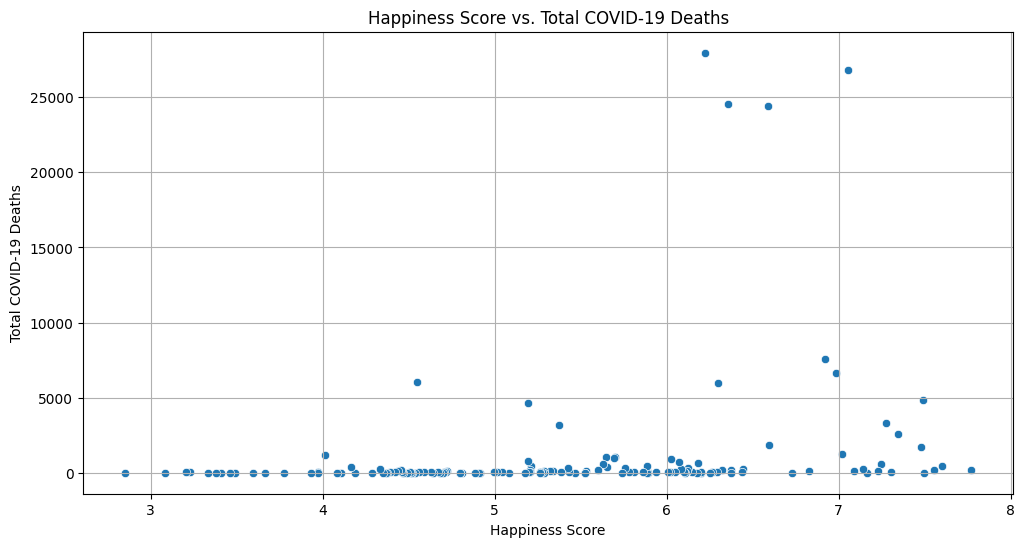

In [12]:
#PLOT 1- Happiness Score V/S Total COVID Deaths
plt.figure(figsize=(12,6))
sns.scatterplot(data=merged, x='Score', y='Total_Deaths')
plt.title('Happiness Score vs. Total COVID-19 Deaths')
plt.xlabel('Happiness Score')
plt.ylabel('Total COVID-19 Deaths')
plt.grid(True)
plt.show()

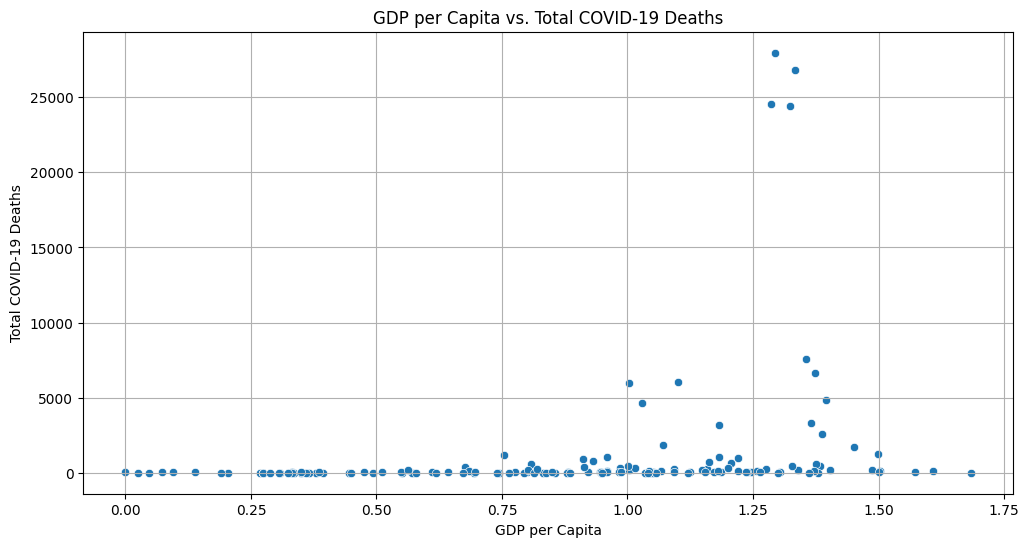

In [13]:
#PLOT 2- GDP Capita V/S Total COVID Deaths
plt.figure(figsize=(12,6))
sns.scatterplot(data=merged, x='GDP per capita', y='Total_Deaths')
plt.title('GDP per Capita vs. Total COVID-19 Deaths')
plt.xlabel('GDP per Capita')
plt.ylabel('Total COVID-19 Deaths')
plt.grid(True)
plt.show()

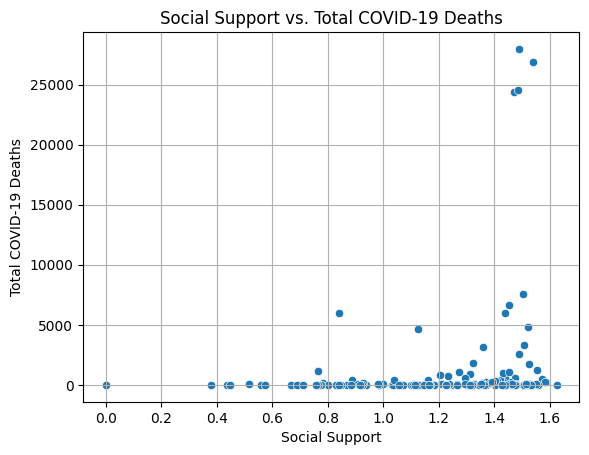

In [14]:
#PLOT 3- Social Support V/S Total COVID plt.figure(figsize=(12,6))
sns.scatterplot(data=merged, x='Social support', y='Total_Deaths')
plt.title('Social Support vs. Total COVID-19 Deaths')
plt.xlabel('Social Support')
plt.ylabel('Total COVID-19 Deaths')
plt.grid(True)
plt.show()

Score                           0.247148
GDP per capita                  0.251383
Social support                  0.206401
Healthy life expectancy         0.295664
Freedom to make life choices    0.009459
Generosity                      0.025282
Perceptions of corruption       0.119767
Total_Deaths                    1.000000
Name: Total_Deaths, dtype: float64


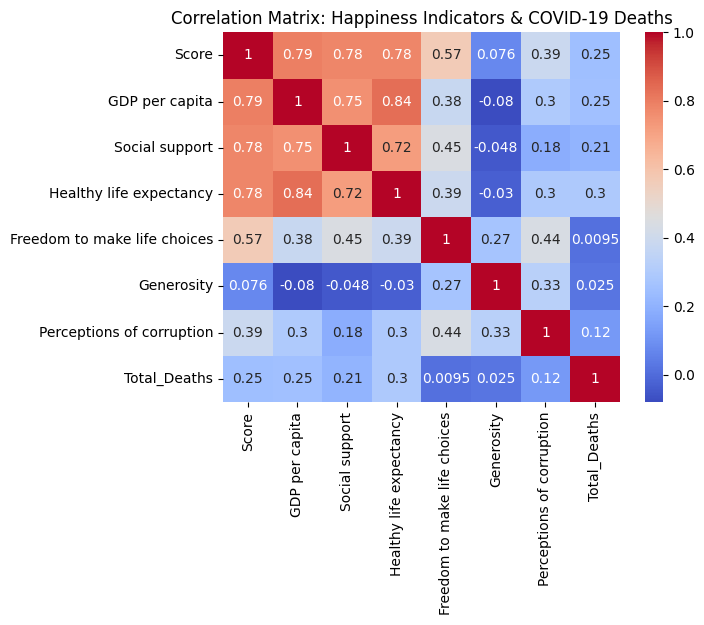

In [15]:
# Correlation matrix for happiness factors and COVID deaths
corr_matrix = merged[['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
                      'Freedom to make life choices', 'Generosity', 'Perceptions of corruption',
                      'Total_Deaths']].corr()
print(corr_matrix['Total_Deaths'])
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Happiness Indicators & COVID-19 Deaths')
plt.show()